
📊 ORIGINAL DATA SHAPE: (500, 9)
  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  

✅ DATA SHAPE AFTER CLEANING: (500, 9)

✅ Scaling completed successfully


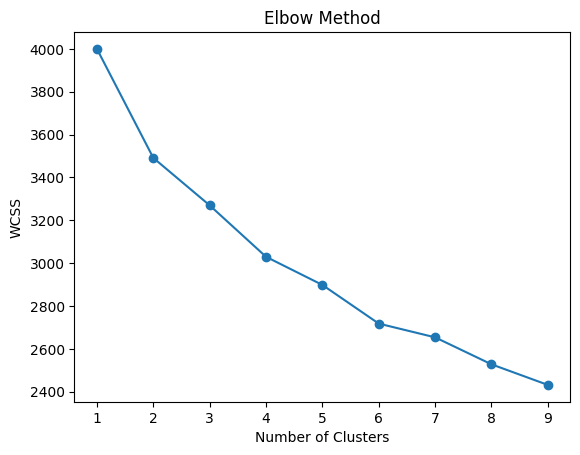


👉 Choose optimal clusters (usually 3)

📌 K-Means Cluster Distribution:
Cluster_KMeans
1    247
2    134
0    119
Name: count, dtype: int64

📌 DBSCAN Cluster Distribution:
Cluster_DBSCAN
-1     356
 8      23
 9      22
 7      10
 13      9
 3       8
 1       8
 4       8
 6       8
 15      7
 12      7
 0       7
 5       6
 11      6
 2       5
 14      5
 10      5
Name: count, dtype: int64

📊 SEGMENT ANALYSIS:
                CustomerID     Tenure  MonthlyCharges  TotalCharges  Contract  \
Cluster_KMeans                                                                  
0               376.411765  30.529412      113.067227   5036.697479  0.848739   
1               247.765182  37.789474      119.684211   4153.246964  0.874494   
2               139.992537  39.544776      102.992537   3684.492537  1.052239   

                PaymentMethod  PaperlessBilling  SeniorCitizen     Churn  \
Cluster_KMeans                                                             
0                    

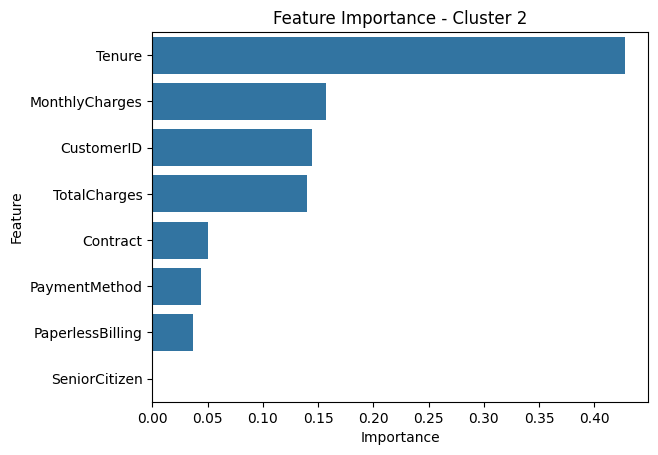


🚀 MODEL FOR CLUSTER 1

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00         5

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50


🔧 Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

🔥 Feature Importance:
            Feature  Importance
1            Tenure    0.592131
0        CustomerID    0.108066
2    MonthlyCharges    0.105812
3      TotalCharges    0.094395
4          Contract    0.056399
5     PaymentMethod    0.024607
6  PaperlessBilling    0.018589
7     SeniorCitizen    0.000000


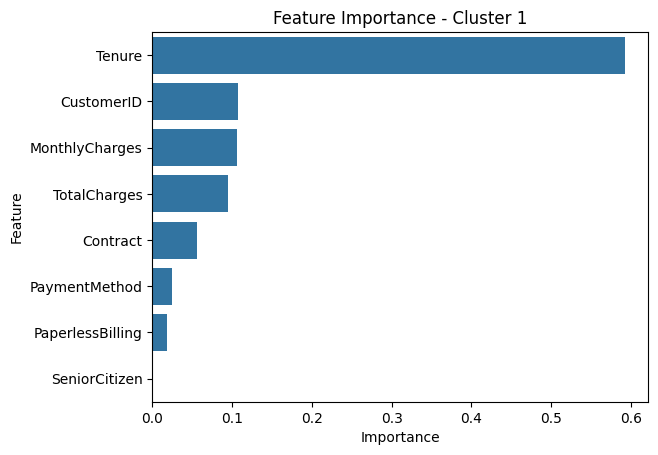


🚀 MODEL FOR CLUSTER 0

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        19
           1       0.67      0.40      0.50         5

    accuracy                           0.83        24
   macro avg       0.76      0.67      0.70        24
weighted avg       0.82      0.83      0.82        24


🔧 Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

🔥 Feature Importance:
            Feature  Importance
1            Tenure    0.488751
0        CustomerID    0.171154
2    MonthlyCharges    0.110468
3      TotalCharges    0.103987
4          Contract    0.068999
5     PaymentMethod    0.028733
6  PaperlessBilling    0.022451
7     SeniorCitizen    0.005457


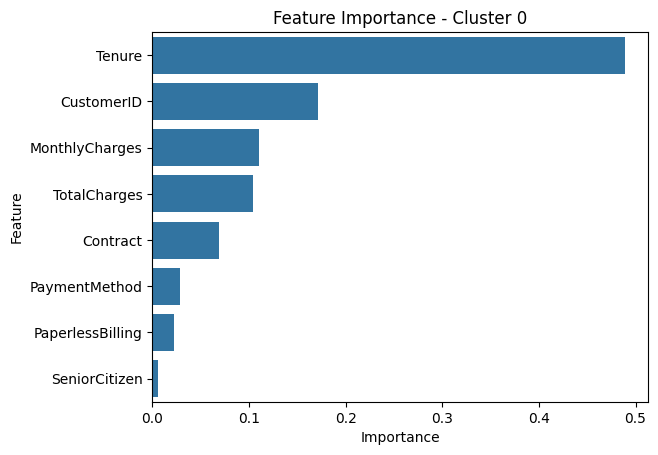


🏁 FINAL MODEL PERFORMANCE:
   Cluster  Accuracy  Precision  Recall   F1   ROC_AUC
0        2  0.925926   0.000000     0.0  0.0  0.980000
1        1  1.000000   1.000000     1.0  1.0  1.000000
2        0  0.833333   0.666667     0.4  0.5  0.884211

✅ SUCCESS: model_evaluation_results.csv generated


In [3]:
# ==========================================================
# CUSTOMER SEGMENTATION & PREDICTION - FIXED PIPELINE
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# ==========================================================
# LOAD DATA
# ==========================================================

df = pd.read_csv("customer_churn.csv")

print("\n📊 ORIGINAL DATA SHAPE:", df.shape)
print(df.head())

# ==========================================================
# DATA CLEANING (FIXED)
# ==========================================================

# Fill missing values instead of dropping everything
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Encode ALL categorical columns safely
for col in df.select_dtypes(include='object').columns:
    df[col] = pd.factorize(df[col])[0]

print("\n✅ DATA SHAPE AFTER CLEANING:", df.shape)

# ==========================================================
# FEATURES & TARGET
# ==========================================================

if 'Churn' not in df.columns:
    raise Exception("❌ 'Churn' column not found in dataset")

X = df.drop('Churn', axis=1)
y = df['Churn']

# ==========================================================
# SCALING
# ==========================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n✅ Scaling completed successfully")

# ==========================================================
# ELBOW METHOD
# ==========================================================

wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

print("\n👉 Choose optimal clusters (usually 3)")

# ==========================================================
# K-MEANS CLUSTERING
# ==========================================================

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

print("\n📌 K-Means Cluster Distribution:")
print(df['Cluster_KMeans'].value_counts())

# ==========================================================
# HIERARCHICAL CLUSTERING
# ==========================================================

agg = AgglomerativeClustering(n_clusters=3)
df['Cluster_Hierarchical'] = agg.fit_predict(X_scaled)

# ==========================================================
# DBSCAN
# ==========================================================

dbscan = DBSCAN(eps=1.5, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

print("\n📌 DBSCAN Cluster Distribution:")
print(df['Cluster_DBSCAN'].value_counts())

# ==========================================================
# SEGMENT ANALYSIS
# ==========================================================

print("\n📊 SEGMENT ANALYSIS:")
segment_summary = df.groupby('Cluster_KMeans').mean(numeric_only=True)
print(segment_summary)

# ==========================================================
# MODEL BUILDING PER SEGMENT
# ==========================================================

results = []

for cluster in df['Cluster_KMeans'].unique():

    print(f"\n==============================")
    print(f"🚀 MODEL FOR CLUSTER {cluster}")
    print(f"==============================")

    segment_df = df[df['Cluster_KMeans'] == cluster]

    if len(segment_df) < 10:
        print("⚠️ Skipping (too few samples)")
        continue

    X_seg = segment_df.drop(
        ['Churn', 'Cluster_KMeans', 'Cluster_Hierarchical', 'Cluster_DBSCAN'],
        axis=1
    )
    y_seg = segment_df['Churn']

    X_train, X_test, y_train, y_test = train_test_split(
        X_seg, y_seg, test_size=0.2, random_state=42
    )

    # Base Model
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    try:
        roc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
    except:
        roc = 0

    print("\n📊 Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # ======================================================
    # HYPERPARAMETER TUNING
    # ======================================================

    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5]
    }

    grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=3,
        scoring='accuracy'
    )

    grid.fit(X_train, y_train)

    print("\n🔧 Best Parameters:", grid.best_params_)

    # ======================================================
    # FEATURE IMPORTANCE
    # ======================================================

    importance_df = pd.DataFrame({
        'Feature': X_seg.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    print("\n🔥 Feature Importance:")
    print(importance_df)

    plt.figure()
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title(f"Feature Importance - Cluster {cluster}")
    plt.show()

    # Store results
    results.append([cluster, acc, prec, rec, f1, roc])

# ==========================================================
# FINAL RESULTS
# ==========================================================

results_df = pd.DataFrame(results, columns=[
    'Cluster', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC'
])

print("\n🏁 FINAL MODEL PERFORMANCE:")
print(results_df)

results_df.to_csv("model_evaluation_results.csv", index=False)

print("\n✅ SUCCESS: model_evaluation_results.csv generated")